# 03 · Análisis y Reportes — Caso Familia Miranda
**Proyecto:** IW Resource Management – Caso Familia Miranda  
**Autor:** Diego Ballesteros  
**Fecha:** 2026  


---

## Objetivo
Responder todas las preguntas del caso de negocio mediante consultas SQL sobre el modelo relacional construido en el notebook 02. Cada sección corresponde directamente a una pregunta del enunciado.

**Meses analizados:** Agosto 2023 · Septiembre 2023

---

## Índice de reportes
1. Setup y conexión
2. Ejecución presupuestal — planeado vs. real por rubro
3. ¿Cuánto gana la familia al mes?
4. ¿Cuánto gasta la familia al mes?
5. ¿Está quedando suficiente dinero para ahorrar?
6. Top 3 rubros con mayor sobreejercicio
7. Medio de pago preferido por miembro
8. Gastos NO registrados en rubros presupuestados
9. Rubros presupuestados NO utilizados en el mes
10. Resumen ejecutivo

---
## 1. Setup y conexión

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sqlalchemy import create_engine, text
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi']     = 120
plt.rcParams['font.family']    = 'DejaVu Sans'
plt.rcParams['axes.titlesize'] = 13

BASE_DIR = Path('..')
DB_PATH  = BASE_DIR / 'data' / 'familia_miranda.db'
PROC_DIR = BASE_DIR / 'data' / 'processed'

engine = create_engine(f'sqlite:///{DB_PATH}', echo=False)


def fmt_cop(val) -> str:
    return f'$ {val:>15,.0f}'


class FamilyAnalyzer:
    """Ejecuta las consultas analiticas sobre la base de datos familiar."""

    def __init__(self, engine, mes: str):
        self.engine = engine
        self.mes    = mes

    def _query(self, sql: str) -> pd.DataFrame:
        with self.engine.connect() as conn:
            return pd.read_sql(text(sql), conn)

    def ejecucion_presupuestal(self) -> pd.DataFrame:
        sql = f"""
            SELECT
                r.nombre_rubro                       AS rubro,
                p.valor_planeado                     AS planeado,
                COALESCE(SUM(g_papa.valor), 0)       AS gasto_papa,
                COALESCE(SUM(g_mama.valor), 0)       AS gasto_mama,
                COALESCE(SUM(g_hijo.valor), 0)       AS gasto_hijo,
                COALESCE(SUM(g_papa.valor), 0)
                    + COALESCE(SUM(g_mama.valor), 0)
                    + COALESCE(SUM(g_hijo.valor), 0) AS total_real,
                p.valor_planeado - (
                    COALESCE(SUM(g_papa.valor), 0)
                    + COALESCE(SUM(g_mama.valor), 0)
                    + COALESCE(SUM(g_hijo.valor), 0)
                )                                    AS diferencia
            FROM presupuesto p
            JOIN rubros r ON p.id_rubro = r.id_rubro
            LEFT JOIN gastos g_papa
                ON g_papa.id_rubro = p.id_rubro AND g_papa.mes = p.mes
                AND g_papa.id_miembro = (SELECT id_miembro FROM miembros WHERE nombre = 'papa')
            LEFT JOIN gastos g_mama
                ON g_mama.id_rubro = p.id_rubro AND g_mama.mes = p.mes
                AND g_mama.id_miembro = (SELECT id_miembro FROM miembros WHERE nombre = 'mama')
            LEFT JOIN gastos g_hijo
                ON g_hijo.id_rubro = p.id_rubro AND g_hijo.mes = p.mes
                AND g_hijo.id_miembro = (SELECT id_miembro FROM miembros WHERE nombre = 'hijo')
            WHERE p.mes = '{self.mes}'
            GROUP BY r.nombre_rubro, p.valor_planeado
            ORDER BY diferencia ASC
        """
        return self._query(sql)

    def ingresos(self) -> pd.DataFrame:
        sql = f"""
            SELECT m.nombre AS miembro,
                   SUM(g.valor)          AS ingreso_real,
                   MAX(p.valor_planeado) AS ingreso_planeado
            FROM gastos g
            JOIN miembros    m ON g.id_miembro = m.id_miembro
            JOIN rubros      r ON g.id_rubro   = r.id_rubro
            JOIN presupuesto p ON p.id_rubro   = g.id_rubro AND p.mes = g.mes
            WHERE g.mes = '{self.mes}'
              AND LOWER(r.nombre_rubro) LIKE '%contrato%'
            GROUP BY m.nombre
            ORDER BY ingreso_real DESC
        """
        return self._query(sql)

    def gastos_totales(self) -> pd.DataFrame:
        sql = f"""
            SELECT m.nombre AS miembro,
                   COUNT(*)     AS num_transacciones,
                   SUM(g.valor) AS total_gasto
            FROM gastos g
            JOIN miembros m ON g.id_miembro = m.id_miembro
            WHERE g.mes = '{self.mes}'
              AND LOWER(COALESCE(g.categoria_origen, '')) NOT LIKE '%contrato%'
            GROUP BY m.nombre
            ORDER BY total_gasto DESC
        """
        return self._query(sql)

    def flujo_caja(self) -> pd.DataFrame:
        sql = """
            SELECT g.mes,
                   SUM(CASE WHEN LOWER(r.nombre_rubro) LIKE '%contrato%'
                            THEN g.valor ELSE 0 END) AS ingresos,
                   SUM(CASE WHEN LOWER(r.nombre_rubro) NOT LIKE '%contrato%'
                            THEN g.valor ELSE 0 END) AS gastos
            FROM gastos g
            LEFT JOIN rubros r ON g.id_rubro = r.id_rubro
            GROUP BY g.mes
            ORDER BY g.mes
        """
        df = self._query(sql)
        df['ahorro']        = df['ingresos'] - df['gastos']
        df['tasa_ahorro_%'] = (df['ahorro'] / df['ingresos'] * 100).round(1)
        return df

    def top_sobreejecucion(self, n: int = 3) -> pd.DataFrame:
        sql = f"""
            SELECT r.nombre_rubro AS rubro,
                   p.valor_planeado                                           AS planeado,
                   SUM(g.valor)                                               AS total_real,
                   SUM(g.valor) - p.valor_planeado                           AS exceso,
                   ROUND((SUM(g.valor) - p.valor_planeado)
                       / p.valor_planeado * 100, 1)                          AS exceso_pct
            FROM presupuesto p
            JOIN rubros r ON p.id_rubro = r.id_rubro
            JOIN gastos g ON g.id_rubro = p.id_rubro AND g.mes = p.mes
            WHERE p.mes = '{self.mes}'
              AND LOWER(r.nombre_rubro) NOT LIKE '%contrato%'
            GROUP BY r.nombre_rubro, p.valor_planeado
            HAVING SUM(g.valor) > p.valor_planeado
            ORDER BY exceso DESC
            LIMIT {n}
        """
        return self._query(sql)

    def medio_pago_preferido(self) -> pd.DataFrame:
        sql = f"""
            SELECT m.nombre AS miembro, g.forma_pago,
                   COUNT(*)     AS frecuencia,
                   SUM(g.valor) AS monto_total
            FROM gastos g
            JOIN miembros m ON g.id_miembro = m.id_miembro
            WHERE g.mes = '{self.mes}'
              AND LOWER(COALESCE(g.categoria_origen, '')) NOT LIKE '%contrato%'
            GROUP BY m.nombre, g.forma_pago
            ORDER BY m.nombre, frecuencia DESC
        """
        return self._query(sql)

    def gastos_sin_rubro(self) -> pd.DataFrame:
        sql = f"""
            SELECT m.nombre AS miembro, g.fecha, g.descripcion,
                   g.categoria_origen AS categoria, g.valor, g.forma_pago
            FROM gastos g
            JOIN miembros m ON g.id_miembro = m.id_miembro
            WHERE g.mes = '{self.mes}' AND g.id_rubro IS NULL
            ORDER BY g.valor DESC
        """
        return self._query(sql)

    def rubros_sin_gasto(self) -> pd.DataFrame:
        sql = f"""
            SELECT r.nombre_rubro AS rubro, p.valor_planeado AS presupuestado
            FROM presupuesto p
            JOIN rubros r ON p.id_rubro = r.id_rubro
            LEFT JOIN gastos g ON g.id_rubro = p.id_rubro AND g.mes = p.mes
            WHERE p.mes = '{self.mes}'
              AND g.id_gasto IS NULL
              AND LOWER(r.nombre_rubro) NOT LIKE '%contrato%'
            ORDER BY p.valor_planeado DESC
        """
        return self._query(sql)


class FamilyVisualizer:
    """Genera las visualizaciones del analisis financiero familiar."""

    def __init__(self, output_dir: Path):
        self.output_dir = output_dir

    def _save(self, filename: str) -> None:
        plt.savefig(self.output_dir / filename, bbox_inches='tight')
        plt.show()

    def plot_ejecucion(self, df: pd.DataFrame, mes: str) -> None:
        df_plot = df[df['total_real'] > 0].nlargest(15, 'total_real')
        x, width = range(len(df_plot)), 0.38
        fig, ax = plt.subplots(figsize=(12, 6))
        ax.bar([i - width/2 for i in x], df_plot['planeado'],   width, label='Planeado', color='#4C72B0', alpha=0.85)
        ax.bar([i + width/2 for i in x], df_plot['total_real'], width, label='Real',     color='#DD8452', alpha=0.85)
        ax.set_xticks(list(x))
        ax.set_xticklabels(df_plot['rubro'], rotation=35, ha='right', fontsize=9)
        ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'${v/1e6:.1f}M'))
        ax.set_title(f'Planeado vs. Real por Rubro — {mes}', fontsize=14, pad=12)
        ax.set_ylabel('Valor (COP)')
        ax.legend()
        plt.tight_layout()
        self._save('ejecucion_presupuestal.png')

    def plot_flujo_caja(self, df: pd.DataFrame) -> None:
        meses, x, width = df['mes'].tolist(), range(len(df['mes'])), 0.28
        fig, ax = plt.subplots(figsize=(8, 5))
        ax.bar([i - width for i in x], df['ingresos'], width, label='Ingresos', color='#55A868', alpha=0.9)
        ax.bar([i          for i in x], df['gastos'],   width, label='Gastos',   color='#DD8452', alpha=0.9)
        ax.bar([i + width  for i in x], df['ahorro'],   width, label='Ahorro',
               color=['#4C72B0' if v >= 0 else '#C44E52' for v in df['ahorro']], alpha=0.9)
        ax.set_xticks(list(x))
        ax.set_xticklabels(meses)
        ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'${v/1e6:.1f}M'))
        ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
        ax.set_title('Flujo de Caja Familiar — Ingresos vs. Gastos vs. Ahorro', pad=12)
        ax.set_ylabel('Valor (COP)')
        ax.legend()
        plt.tight_layout()
        self._save('flujo_caja.png')

    def plot_top_sobreejecucion(self, df: pd.DataFrame, mes: str) -> None:
        colores = ['#C44E52', '#DD8452', '#CCB974']
        fig, ax = plt.subplots(figsize=(8, 4))
        bars = ax.barh(df['rubro'], df['exceso'], color=colores[:len(df)], alpha=0.9)
        for bar, pct in zip(bars, df['exceso_pct']):
            ax.text(bar.get_width() * 1.01, bar.get_y() + bar.get_height()/2,
                    f'+{pct}%', va='center', fontsize=10, color='#333')
        ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'${v/1e6:.1f}M'))
        ax.set_title(f'Top 3 Rubros — Mayor Sobreejercicio ({mes})', pad=12)
        ax.set_xlabel('Exceso sobre lo presupuestado (COP)')
        ax.invert_yaxis()
        plt.tight_layout()
        self._save('top3_sobreejercicio.png')

    def plot_medios_pago(self, df: pd.DataFrame, mes: str) -> None:
        fig, axes = plt.subplots(1, 3, figsize=(12, 4))
        for ax, miembro in zip(axes, ['papa', 'mama', 'hijo']):
            df_m = df[df['miembro'] == miembro]
            if df_m.empty:
                ax.set_visible(False)
                continue
            ax.pie(df_m['frecuencia'], labels=df_m['forma_pago'],
                   autopct='%1.1f%%', startangle=90,
                   colors=sns.color_palette('muted', len(df_m)))
            ax.set_title(miembro.capitalize(), fontsize=12)
        fig.suptitle(f'Distribucion de Medios de Pago por Miembro — {mes}', fontsize=13, y=1.02)
        plt.tight_layout()
        self._save('medios_pago.png')

    def plot_comparativo(self, df: pd.DataFrame) -> None:
        fig, axes = plt.subplots(1, 2, figsize=(12, 5))
        x, width = range(len(df)), 0.25
        ax = axes[0]
        ax.bar([i - width for i in x], df['Ingresos'], width, label='Ingresos', color='#55A868', alpha=0.9)
        ax.bar([i          for i in x], df['Gastos'],   width, label='Gastos',   color='#DD8452', alpha=0.9)
        ax.bar([i + width  for i in x], df['Ahorro'],   width, label='Ahorro',
               color=['#C44E52' if v < 0 else '#4C72B0' for v in df['Ahorro']], alpha=0.9)
        ax.set_xticks(list(x))
        ax.set_xticklabels(['Agosto', 'Septiembre'])
        ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'${v/1e6:.0f}M'))
        ax.axhline(0, color='black', linewidth=0.7, linestyle='--')
        ax.set_title('Ingresos · Gastos · Ahorro', fontsize=12)
        ax.legend(fontsize=9)
        ax.set_ylabel('COP')

        ax2 = axes[1]
        colores_tasa = ['#C44E52' if v < 0 else '#55A868' for v in df['Tasa ahorro %']]
        bars = ax2.bar(['Agosto', 'Septiembre'], df['Tasa ahorro %'], color=colores_tasa, alpha=0.9)
        for bar, val in zip(bars, df['Tasa ahorro %']):
            ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                     f'{val:.1f}%', ha='center', va='bottom', fontsize=12, fontweight='bold')
        ax2.axhline(20, color='orange', linewidth=1.5, linestyle='--', label='Meta 20% ahorro')
        ax2.axhline(0,  color='black',  linewidth=0.7, linestyle='--')
        ax2.set_title('Tasa de Ahorro (%)', fontsize=12)
        ax2.set_ylabel('% del ingreso')
        ax2.legend(fontsize=9)

        plt.suptitle('Comparativo Mensual — Familia Miranda', fontsize=14, fontweight='bold')
        plt.tight_layout()
        self._save('comparativo_meses.png')


MES        = '2023-09'
analyzer   = FamilyAnalyzer(engine, MES)
visualizer = FamilyVisualizer(PROC_DIR)

print(f'Conexion establecida: {DB_PATH.resolve()}')
print(f'Mes de analisis     : {MES}')


Conexion establecida: /home/diego/iw-proyecto/data/familia_miranda.db
Mes de analisis     : 2023-09


---
## 2. Ejecución presupuestal — Planeado vs. Real por rubro

> **Pregunta:** Obtenga la información de los gastos de cada miembro, haga la sumatoria en el campo Real cruzando por el nombre del rubro. ¿Cuál es el resultado de la ejecución presupuestal?

Esta consulta es el corazón del análisis: une el presupuesto con los gastos reales de los tres miembros para calcular la diferencia por rubro.

In [2]:
df_ejec = analyzer.ejecucion_presupuestal()

df_display = df_ejec.copy()
for col in ['planeado', 'gasto_papa', 'gasto_mama', 'gasto_hijo', 'total_real', 'diferencia']:
    df_display[col] = df_display[col].apply(lambda x: f'$ {x:>12,.0f}')

print(f'EJECUCION PRESUPUESTAL — {MES}')
print('=' * 95)
print(df_display.to_string(index=False))


EJECUCION PRESUPUESTAL — 2023-09
                          rubro       planeado     gasto_papa     gasto_mama     gasto_hijo      total_real       diferencia
                 COMIDAS AFUERA $    5,000,000 $  783,478,800 $  809,643,120 $  770,404,800 $ 2,363,526,720 $ -2,358,526,720
DEPORTE ENTRENO + INSCRIPCIONES $    4,000,000 $   12,384,000 $   11,160,000 $   17,650,000  $   41,194,000   $  -37,194,000
                        MERCADO $    1,600,000 $    6,461,316 $    7,029,612 $            0  $   13,490,928   $  -11,890,928
                         VIAJES $       30,000 $      906,000 $      735,000 $            0  $    1,641,000   $   -1,611,000
            AYUDAS A FAMILIARES $      500,000 $      785,700 $      980,000 $      165,000  $    1,930,700   $   -1,430,700
              PAGO TARJETA NUBE $    1,500,000 $    2,843,921 $            0 $            0  $    2,843,921   $   -1,343,921
 TRANSPORTE CARRO/MOTO/GASOLINA $      150,000 $      360,000 $      516,000 $      280,000 

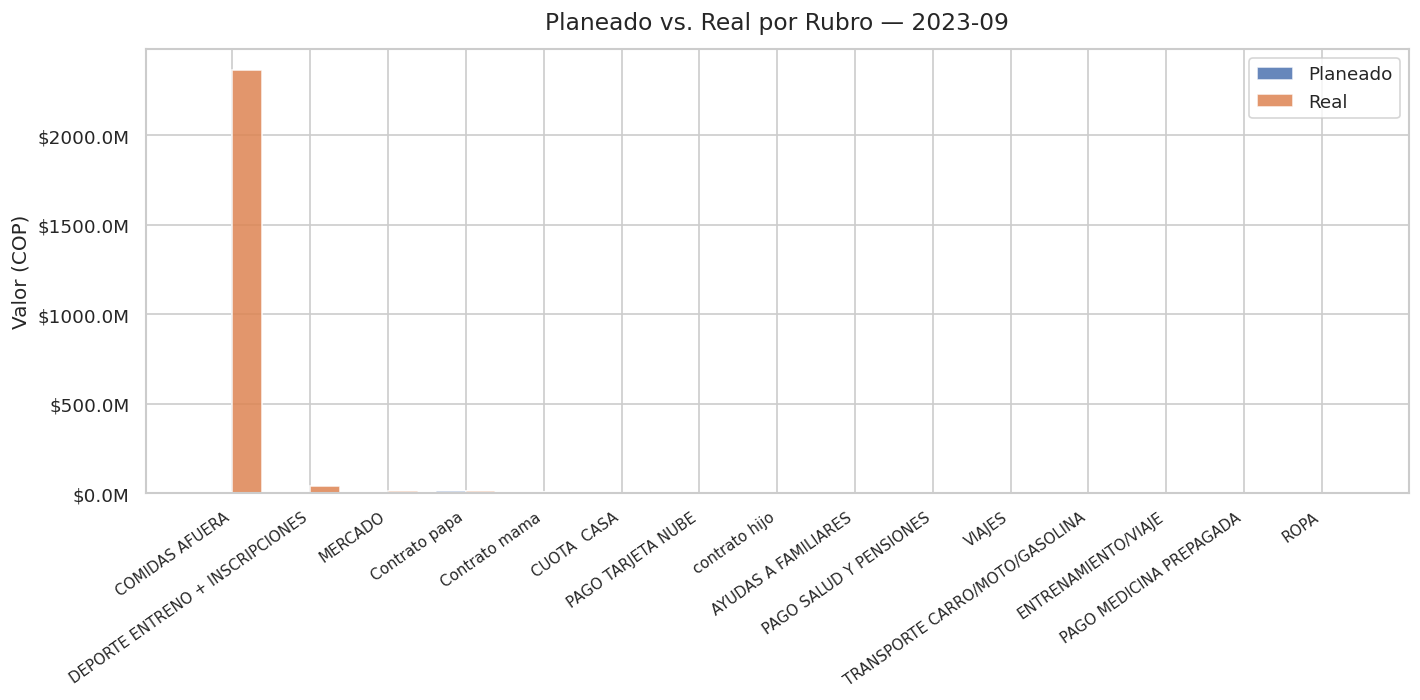

In [3]:
visualizer.plot_ejecucion(df_ejec, MES)


---
## 3. ¿Cuánto dinero gana la familia al mes?

> **Pregunta:** ¿Cuánto dinero gana la familia al mes?

In [4]:
df_ingresos   = analyzer.ingresos()
total_ingreso = df_ingresos['ingreso_real'].sum()

print(f'INGRESOS FAMILIA MIRANDA — {MES}')
print('-' * 45)
for _, row in df_ingresos.iterrows():
    print(f"  {row['miembro']:<8}  {fmt_cop(row['ingreso_real'])}")
print('-' * 45)
print(f"  {'TOTAL':<8}  {fmt_cop(total_ingreso)}")


INGRESOS FAMILIA MIRANDA — 2023-09
---------------------------------------------
  papa      $      10,574,000
  mama      $       8,500,000
  hijo      $       2,500,000
---------------------------------------------
  TOTAL     $      21,574,000


---
## 4. ¿Cuánto gasta la familia al mes?

> **Pregunta:** ¿Cuánto dinero gastó la familia al mes?

In [5]:
df_gastos_total = analyzer.gastos_totales()
total_gasto     = df_gastos_total['total_gasto'].sum()

print(f'GASTOS FAMILIA MIRANDA — {MES}')
print('-' * 55)
for _, row in df_gastos_total.iterrows():
    print(f"  {row['miembro']:<8}  {row['num_transacciones']:>3} transacciones  {fmt_cop(row['total_gasto'])}")
print('-' * 55)
print(f"  {'TOTAL':<8}  {df_gastos_total['num_transacciones'].sum():>3} transacciones  {fmt_cop(total_gasto)}")


GASTOS FAMILIA MIRANDA — 2023-09
-------------------------------------------------------
  papa      125 transacciones  $      14,613,628
  mama       45 transacciones  $       3,707,858
  hijo       55 transacciones  $       3,177,360
-------------------------------------------------------
  TOTAL     225 transacciones  $      21,498,846


---
## 5. ¿Está quedando suficiente dinero para ahorrar?

> **Pregunta:** ¿La familia está gastando más de lo que gana? ¿Está quedando suficiente dinero para ahorrar?

In [6]:
df_flujo = analyzer.flujo_caja()

print('FLUJO DE CAJA — INGRESOS vs. GASTOS')
print('=' * 70)
for _, row in df_flujo.iterrows():
    estado = 'SUPERAVIT' if row['ahorro'] >= 0 else 'DEFICIT'
    print(f"  {row['mes']}")
    print(f"    Ingresos : {fmt_cop(row['ingresos'])}")
    print(f"    Gastos   : {fmt_cop(row['gastos'])}")
    print(f"    Ahorro   : {fmt_cop(row['ahorro'])}  [{estado}]  ({row['tasa_ahorro_%']}% del ingreso)")
    print()


FLUJO DE CAJA — INGRESOS vs. GASTOS
  2023-08
    Ingresos : $      19,074,000
    Gastos   : $      93,239,595
    Ahorro   : $     -74,165,595  [DEFICIT]  (-388.8% del ingreso)

  2023-09
    Ingresos : $      21,574,000
    Gastos   : $      21,498,846
    Ahorro   : $          75,154  [SUPERAVIT]  (0.3% del ingreso)



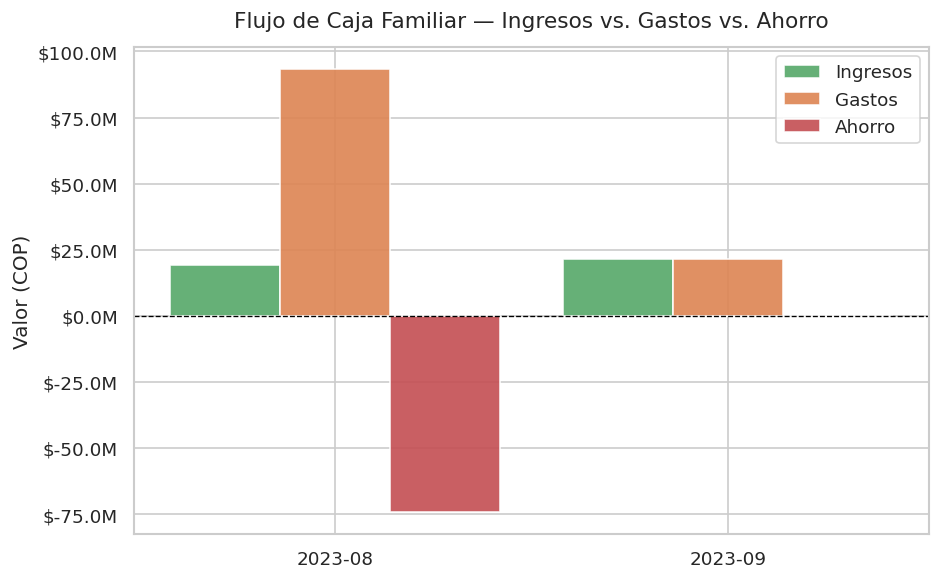

In [7]:
visualizer.plot_flujo_caja(df_flujo)


---
## 6. Top 3 rubros con mayor sobreejercicio presupuestal

> **Pregunta:** ¿Cuál es el top 3 de los rubros que están gastando más dinero del presupuestado?

In [8]:
df_top3 = analyzer.top_sobreejecucion()

print(f'TOP 3 RUBROS CON MAYOR SOBREEJERCICIO — {MES}')
print('=' * 65)
for i, row in df_top3.iterrows():
    print(f"  #{i+1} {row['rubro']}")
    print(f"      Planeado : {fmt_cop(row['planeado'])}")
    print(f"      Real     : {fmt_cop(row['total_real'])}")
    print(f"      Exceso   : {fmt_cop(row['exceso'])}  (+{row['exceso_pct']}%)")
    print()


TOP 3 RUBROS CON MAYOR SOBREEJERCICIO — 2023-09
  #1 PAGO TARJETA NUBE
      Planeado : $       1,500,000
      Real     : $       2,843,921
      Exceso   : $       1,343,921  (+89.6%)

  #2 CUOTA  CASA
      Planeado : $       3,700,000
      Real     : $       4,200,000
      Exceso   : $         500,000  (+13.5%)

  #3 VIAJES
      Planeado : $          30,000
      Real     : $         407,000
      Exceso   : $         377,000  (+1256.7%)



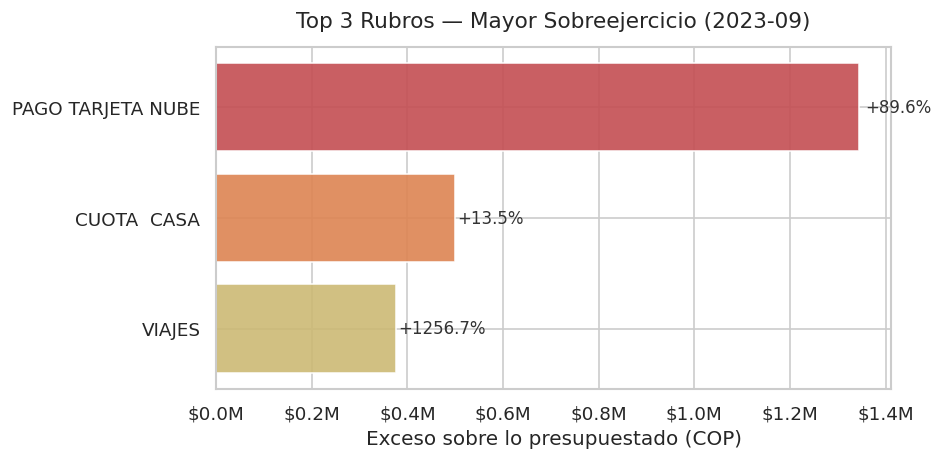

In [9]:
visualizer.plot_top_sobreejecucion(df_top3, MES)


---
## 7. Medio de pago preferido por miembro

> **Pregunta:** ¿Cuál es el tipo de pago preferido de cada miembro de la familia?

In [10]:
df_pago = analyzer.medio_pago_preferido()

print(f'MEDIO DE PAGO POR MIEMBRO — {MES}')
print('=' * 60)
for miembro in df_pago['miembro'].unique():
    df_m      = df_pago[df_pago['miembro'] == miembro].reset_index(drop=True)
    preferido = df_m.iloc[0]
    print(f"  {miembro.upper()}")
    print(f"    Preferido: {preferido['forma_pago']:<15} ({preferido['frecuencia']} transacciones)")
    for _, row in df_m.iterrows():
        pct   = row['frecuencia'] / df_m['frecuencia'].sum() * 100
        barra = '#' * int(pct / 5)
        print(f"      {row['forma_pago']:<15} {barra:<20} {pct:>5.1f}%  {fmt_cop(row['monto_total'])}")
    print()


MEDIO DE PAGO POR MIEMBRO — 2023-09
  HIJO
    Preferido: efectivo        (55 transacciones)
      efectivo        #################### 100.0%  $       3,177,360

  MAMA
    Preferido: Debito          (45 transacciones)
      Debito          #################### 100.0%  $       3,707,858

  PAPA
    Preferido: efectivo        (66 transacciones)
      efectivo        ##########            52.8%  $       1,432,000
      Debito          #########             46.4%  $      11,989,236
      Credito                                0.8%  $       1,192,392



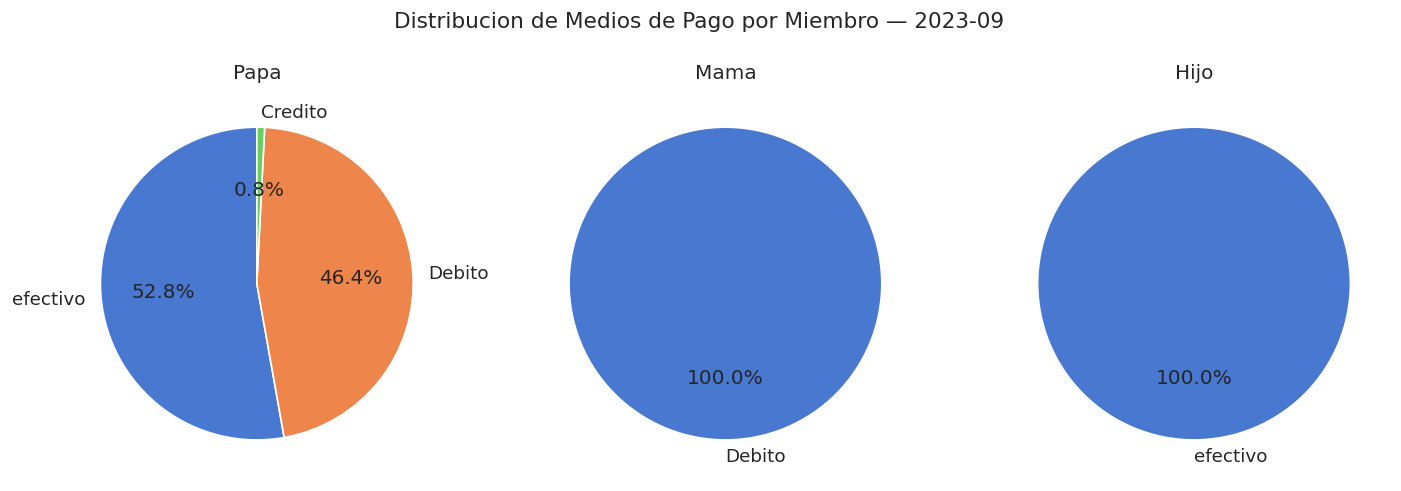

In [11]:
visualizer.plot_medios_pago(df_pago, MES)




## 8. Gastos NO registrados en rubros presupuestados

> **Pregunta:** ¿Cuáles gastos NO están en rubros presupuestados?

In [12]:
df_sin_rubro       = analyzer.gastos_sin_rubro()
total_sin_rubro    = df_sin_rubro['valor'].sum()

print(f'GASTOS SIN RUBRO PRESUPUESTADO — {MES}')
print(f'Total: {len(df_sin_rubro)} transacciones por {fmt_cop(total_sin_rubro)}')
print('=' * 80)
resumen = (
    df_sin_rubro
    .groupby('categoria')
    .agg(transacciones=('valor', 'count'), total=('valor', 'sum'))
    .sort_values('total', ascending=False)
)
resumen['total_fmt'] = resumen['total'].apply(fmt_cop)
print(resumen[['transacciones', 'total_fmt']].to_string())


GASTOS SIN RUBRO PRESUPUESTADO — 2023-09
Total: 0 transacciones por $               0
Empty DataFrame
Columns: [transacciones, total_fmt]
Index: []



## 9. Rubros presupuestados NO utilizados en el mes

In [13]:
df_sin_gasto    = analyzer.rubros_sin_gasto()
total_no_usado  = df_sin_gasto['presupuestado'].sum()

print(f'RUBROS PRESUPUESTADOS SIN GASTO REGISTRADO — {MES}')
print(f'({len(df_sin_gasto)} rubros · {fmt_cop(total_no_usado)} no ejecutados)')
print('=' * 55)
for _, row in df_sin_gasto.iterrows():
    print(f"  {row['rubro']:<40} {fmt_cop(row['presupuestado'])}")


RUBROS PRESUPUESTADOS SIN GASTO REGISTRADO — 2023-09
(7 rubros · $      10,465,287 no ejecutados)
  CDT compra carro                         $      10,000,000
  GATAS                                    $         200,000
  TRANSPORTE BUS                           $         150,000
  PAGO COOPERATIVA                         $         100,287
  CUOTA NETFLIX                            $          15,000
  PAGO GOOGLE                              $               0
  TECNOLOGIA                               $               0



## 10. Resumen ejecutivo

Consolidación de los hallazgos principales para presentación ante el evaluador.

In [14]:
total_ing = df_ingresos['ingreso_real'].sum()
total_gto = df_gastos_total['total_gasto'].sum()
ahorro    = total_ing - total_gto
tasa_ah   = ahorro / total_ing * 100 if total_ing > 0 else 0

print('=' * 65)
print(f'  RESUMEN EJECUTIVO — FAMILIA MIRANDA — {MES}')
print('=' * 65)
print(f"  Ingresos totales       : {fmt_cop(total_ing)}")
print(f"  Gastos totales         : {fmt_cop(total_gto)}")
print(f"  Ahorro neto            : {fmt_cop(ahorro)}  ({tasa_ah:.1f}% del ingreso)")
print(f"  Estado                 : {'SUPERAVIT' if ahorro >= 0 else 'DEFICIT'}")
print()
print(f"  Gastos sin presupuesto : {len(df_sin_rubro)} transacciones · {fmt_cop(total_sin_rubro)}")
print(f"  Rubros sin usar        : {len(df_sin_gasto)} rubros · {fmt_cop(total_no_usado)} disponibles")
print()
print('  Top 3 rubros sobre ejecutados:')
for i, row in df_top3.iterrows():
    print(f"    #{i+1} {row['rubro']:<35} +{row['exceso_pct']}%")
print('=' * 65)


  RESUMEN EJECUTIVO — FAMILIA MIRANDA — 2023-09
  Ingresos totales       : $      21,574,000
  Gastos totales         : $      21,498,846
  Ahorro neto            : $          75,154  (0.3% del ingreso)
  Estado                 : SUPERAVIT

  Gastos sin presupuesto : 0 transacciones · $               0
  Rubros sin usar        : 7 rubros · $      10,465,287 disponibles

  Top 3 rubros sobre ejecutados:
    #1 PAGO TARJETA NUBE                   +89.6%
    #2 CUOTA  CASA                         +13.5%
    #3 VIAJES                              +1256.7%



## 11. Análisis completo — Agosto 2023 

> El nivel Senior exige analizar **ambos meses**. Las secciones anteriores cubren Septiembre 2023.
> Esta sección replica los reportes principales para Agosto 2023.
>
> **Nota:** El hijo no tiene archivo de gastos para agosto — solo Papá y Mamá.

In [15]:
analyzer_ago = FamilyAnalyzer(engine, '2023-08')
df_ejec_ago  = analyzer_ago.ejecucion_presupuestal()

df_disp_ago = df_ejec_ago.copy()
cols_fmt = [c for c in ['planeado', 'gasto_papa', 'gasto_mama', 'gasto_hijo', 'total_real', 'diferencia']
            if c in df_disp_ago.columns]
for col in cols_fmt:
    df_disp_ago[col] = df_disp_ago[col].apply(lambda x: f'$ {x:>12,.0f}')

print('EJECUCION PRESUPUESTAL — 2023-08 (Papa + Mama, sin Hijo)')
print('=' * 85)
print(df_disp_ago.to_string(index=False))


EJECUCION PRESUPUESTAL — 2023-08 (Papa + Mama, sin Hijo)
                          rubro       planeado     gasto_papa     gasto_mama     gasto_hijo     total_real     diferencia
                 COMIDAS AFUERA $    2,500,000 $   13,057,980 $   16,417,280 $            0 $   29,475,260 $  -26,975,260
                        MERCADO $    1,600,000 $    1,789,986 $    4,061,125 $            0 $    5,851,111 $   -4,251,111
                       PRESTAMO $            0 $    2,000,000 $            0 $            0 $    2,000,000 $   -2,000,000
              PAGO TARJETA NUBE $    1,500,000 $    2,843,921 $            0 $            0 $    2,843,921 $   -1,343,921
                         VIAJES $       30,000 $      576,000 $      525,000 $            0 $    1,101,000 $   -1,071,000
                         LIBROS $       50,000 $      148,000 $      148,000 $            0 $      296,000 $     -246,000
 TRANSPORTE CARRO/MOTO/GASOLINA $      150,000 $      120,000 $      172,000 $           

In [16]:
df_top3_ago = analyzer_ago.top_sobreejecucion()

print('TOP 3 RUBROS CON MAYOR SOBREEJERCICIO — 2023-08')
print('=' * 65)
for i, row in df_top3_ago.iterrows():
    print(f"  #{i+1} {row['rubro']}")
    print(f"      Planeado : {fmt_cop(row['planeado'])}")
    print(f"      Real     : {fmt_cop(row['total_real'])}")
    print(f"      Exceso   : {fmt_cop(row['exceso'])}  (+{row['exceso_pct']}%)")
    print()


TOP 3 RUBROS CON MAYOR SOBREEJERCICIO — 2023-08
  #1 PRESTAMO
      Planeado : $               0
      Real     : $       2,000,000
      Exceso   : $       2,000,000  (+nan%)

  #2 PAGO TARJETA NUBE
      Planeado : $       1,500,000
      Real     : $       2,843,921
      Exceso   : $       1,343,921  (+89.6%)

  #3 VIAJES
      Planeado : $          30,000
      Real     : $         297,000
      Exceso   : $         267,000  (+890.0%)



In [17]:
df_pago_ago = analyzer_ago.medio_pago_preferido()

print('MEDIO DE PAGO POR MIEMBRO — 2023-08')
print('=' * 60)
for miembro in df_pago_ago['miembro'].unique():
    df_m      = df_pago_ago[df_pago_ago['miembro'] == miembro].reset_index(drop=True)
    preferido = df_m.iloc[0]
    print(f"  {miembro.upper()}")
    print(f"    Preferido: {preferido['forma_pago']:<15} ({preferido['frecuencia']} transacciones)")
    for _, row in df_m.iterrows():
        pct   = row['frecuencia'] / df_m['frecuencia'].sum() * 100
        barra = '#' * int(pct / 5)
        print(f"      {row['forma_pago']:<15} {barra:<20} {pct:>5.1f}%  {fmt_cop(row['monto_total'])}")
    print()


MEDIO DE PAGO POR MIEMBRO — 2023-08
  MAMA
    Preferido: Debito          (26 transacciones)
      Debito          #################### 100.0%  $      41,925,697

  PAPA
    Preferido: efectivo        (61 transacciones)
      efectivo        ##########            52.6%  $       1,179,200
      Debito          #########             46.6%  $      48,942,306
      Credito                                0.9%  $       1,192,392



In [18]:
df_sr_ago = analyzer_ago.gastos_sin_rubro()
print('GASTOS SIN RUBRO PRESUPUESTADO — 2023-08')
print(f'Total: {len(df_sr_ago)} transacciones por {fmt_cop(df_sr_ago["valor"].sum())}')
print('=' * 70)
resumen_ago = (
    df_sr_ago.groupby('categoria')
    .agg(transacciones=('valor', 'count'), total=('valor', 'sum'))
    .sort_values('total', ascending=False)
)
resumen_ago['total_fmt'] = resumen_ago['total'].apply(fmt_cop)
print(resumen_ago[['transacciones', 'total_fmt']].to_string())

print()
df_rsg_ago = analyzer_ago.rubros_sin_gasto()
print(f'RUBROS SIN GASTO — 2023-08 ({len(df_rsg_ago)} rubros)')
print('=' * 55)
for _, row in df_rsg_ago.iterrows():
    print(f"  {row['rubro']:<40} {fmt_cop(row['presupuestado'])}")


GASTOS SIN RUBRO PRESUPUESTADO — 2023-08
Total: 0 transacciones por $               0
Empty DataFrame
Columns: [transacciones, total_fmt]
Index: []

RUBROS SIN GASTO — 2023-08 (10 rubros)
  CDT compra carro                         $      10,000,000
  CUOTA CASA                               $       3,700,000
  OFRENDAS FAMILIA                         $         500,000
  ENTRETENIMIENTO/VIAJE                    $         500,000
  GATAS                                    $         200,000
  TRANSPORTE BUS                           $         150,000
  PAGO COOPERATIVA                         $         100,287
  PAGO INTERNET                            $          85,000
  CUOTA NETFLIX                            $          15,000
  PAGO GOOGLE                              $               0


---
## 12. Comparativo Agosto vs. Septiembre 

Tabla comparativa de los KPIs principales entre ambos meses.

COMPARATIVO MENSUAL — FAMILIA MIRANDA
KPI                                Agosto 2023      Septiembre 2023
---------------------------------------------------------------------------
  Ingresos                   $      19,074,000    $      21,574,000
  Gastos                     $      93,239,595    $      21,498,846
  Ahorro                     $     -74,165,595    $          75,154
  Tasa ahorro %                        -388.8%                 0.3%
  Gastos sin presupuesto                     0                    0



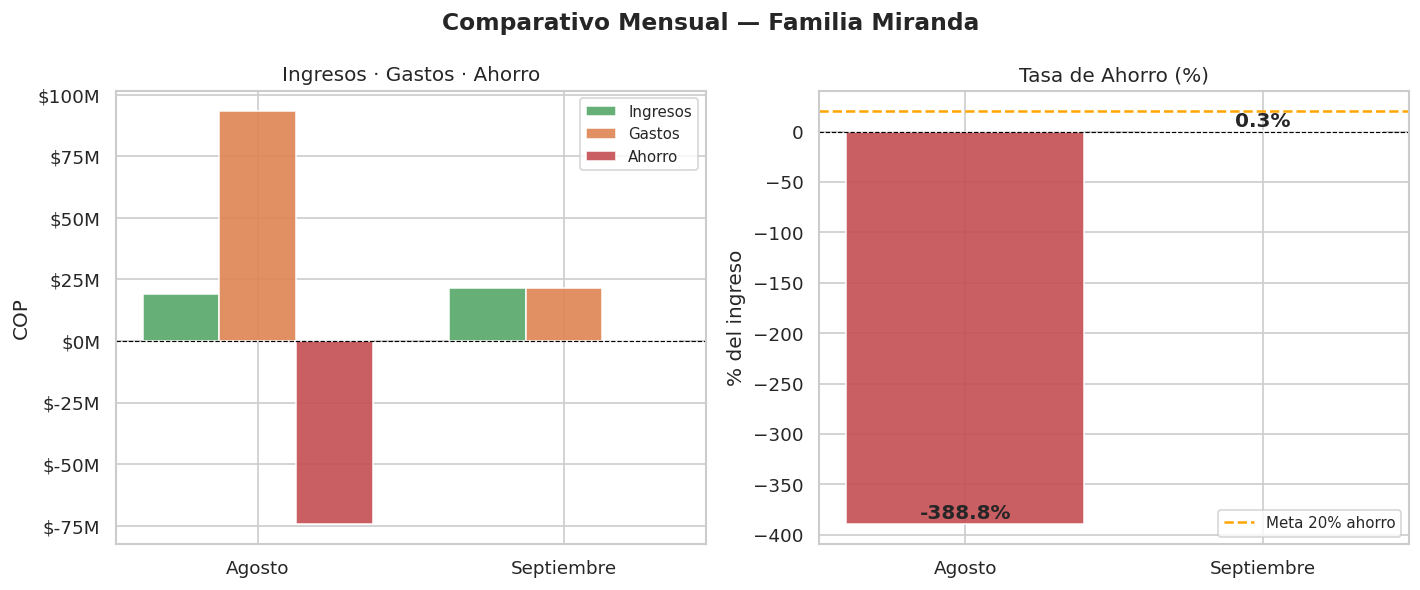

In [19]:
comparativo = []
for mes in ['2023-08', '2023-09']:
    anl    = FamilyAnalyzer(engine, mes)
    ing    = anl.ingresos()['ingreso_real'].sum()
    gto    = anl.gastos_totales()['total_gasto'].sum()
    sr     = anl.gastos_sin_rubro()
    ahorro = ing - gto
    tasa   = ahorro / ing * 100 if ing > 0 else 0
    comparativo.append({
        'Mes'            : mes,
        'Ingresos'       : ing,
        'Gastos'         : gto,
        'Ahorro'         : ahorro,
        'Tasa ahorro %'  : round(tasa, 1),
        'Gastos sin ppto': len(sr),
    })

df_comp = pd.DataFrame(comparativo)

print('COMPARATIVO MENSUAL — FAMILIA MIRANDA')
print('=' * 75)
print(f"{'KPI':<25} {'Agosto 2023':>20} {'Septiembre 2023':>20}")
print('-' * 75)
for kpi in ['Ingresos', 'Gastos', 'Ahorro']:
    val_ago = df_comp[df_comp['Mes'] == '2023-08'][kpi].values[0]
    val_sep = df_comp[df_comp['Mes'] == '2023-09'][kpi].values[0]
    print(f"  {kpi:<23} {fmt_cop(val_ago):>20} {fmt_cop(val_sep):>20}")

tasa_ago = df_comp[df_comp['Mes'] == '2023-08']['Tasa ahorro %'].values[0]
tasa_sep = df_comp[df_comp['Mes'] == '2023-09']['Tasa ahorro %'].values[0]
ppto_ago = df_comp[df_comp['Mes'] == '2023-08']['Gastos sin ppto'].values[0]
ppto_sep = df_comp[df_comp['Mes'] == '2023-09']['Gastos sin ppto'].values[0]
print(f"  {'Tasa ahorro %':<23} {tasa_ago:>19.1f}% {tasa_sep:>19.1f}%")
print(f"  {'Gastos sin presupuesto':<23} {ppto_ago:>20} {ppto_sep:>20}")
print()

visualizer.plot_comparativo(df_comp)
